In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
import random
import warnings
warnings.filterwarnings("ignore")

random.seed(42)
np.random.seed(42)

print("✅ Dependencies loaded.")

✅ Dependencies loaded.


In [3]:
@dataclass
class Ticket:
    id: int
    description: str
    true_priority: str
    proxy_resolution_time: float

@dataclass
class AgentWeights:
    w_speed: float = 0.5
    w_quality: float = 0.5

    def copy(self):
        return AgentWeights(self.w_speed, self.w_quality)

@dataclass
class RoutingDecision:
    ticket_id: int
    queue: str
    confidence: float
    speed_score: float
    quality_score: float

print("✅ Data classes defined.")

✅ Data classes defined.


In [4]:
def generate_ticket_batch(n: int = 10) -> List[Ticket]:
    priorities = ['critical', 'high', 'normal']
    weights_dist = [0.2, 0.3, 0.5]
    tickets = []
    for i in range(n):
        priority = random.choices(priorities, weights=weights_dist)[0]
        if priority == 'critical':
            proxy_time = random.uniform(4.0, 8.0)
        elif priority == 'high':
            proxy_time = random.uniform(2.0, 5.0)
        else:
            proxy_time = random.uniform(0.5, 2.0)
        tickets.append(Ticket(i, f"Ticket #{i}", priority, proxy_time))
    return tickets

print("✅ Ticket generator ready.")

✅ Ticket generator ready.


In [5]:
class Executor:
    def __init__(self, weights: AgentWeights):
        self.weights = weights

    def route(self, ticket: Ticket) -> RoutingDecision:
        speed_score = 1.0 / (ticket.proxy_resolution_time + 0.1)
        quality_map = {'critical': 0.9, 'high': 0.6, 'normal': 0.3}
        quality_score = quality_map[ticket.true_priority]
        decision_score = (self.weights.w_speed * speed_score +
                          self.weights.w_quality * quality_score)
        if decision_score > 0.6:
            queue = 'specialist'
        else:
            queue = 'general'
        return RoutingDecision(
            ticket_id=ticket.id,
            queue=queue,
            confidence=decision_score,
            speed_score=speed_score,
            quality_score=quality_score
        )

print("✅ Executor ready.")

✅ Executor ready.


In [6]:
class Evaluator:
    def score_proxy(self, decision: RoutingDecision) -> float:
        return min(decision.speed_score * 1.5, 1.0)

    def score_grounded(self, decision: RoutingDecision,
                       ticket: Ticket) -> float:
        if ticket.true_priority == 'critical' and decision.queue == 'specialist':
            return 0.95
        elif ticket.true_priority == 'critical' and decision.queue == 'general':
            return 0.1
        elif ticket.true_priority == 'high' and decision.queue == 'specialist':
            return 0.75
        elif ticket.true_priority == 'normal' and decision.queue == 'general':
            return 0.85
        else:
            return 0.5

print("✅ Evaluator ready.")

✅ Evaluator ready.


In [7]:
class MetaReasoner:
    def propose_update(self, scores: List[float],
                       current_weights: AgentWeights,
                       feedback_type: str) -> Dict:
        avg_score = np.mean(scores)
        delta = 0.05 * (avg_score - 0.5)
        if feedback_type == 'proxy':
            proposed = AgentWeights(
                w_speed=np.clip(current_weights.w_speed + delta, 0.1, 0.9),
                w_quality=np.clip(current_weights.w_quality - delta * 0.5, 0.1, 0.9)
            )
        else:
            proposed = AgentWeights(
                w_speed=np.clip(current_weights.w_speed - delta * 0.3, 0.1, 0.9),
                w_quality=np.clip(current_weights.w_quality + delta, 0.1, 0.9)
            )
        return {
            'proposed_weights': proposed,
            'avg_score': avg_score,
            'delta': delta,
            'feedback_type': feedback_type
        }

print("✅ MetaReasoner ready.")

✅ MetaReasoner ready.


In [8]:
class WeightUpdater:
    def __init__(self, grounded: bool = True):
        self.grounded = grounded
        self.update_log = []

    def grounding_check_passes(self, proposed_update: Dict,
                                ground_truth_ref: Optional[float]) -> bool:
        if ground_truth_ref is None:
            return False
        if proposed_update['proposed_weights'].w_quality < 0.3:
            return False
        if ground_truth_ref < 0.2:
            return False
        return True

    def commit(self, proposed_update: Dict,
               ground_truth_ref: Optional[float] = None) -> Tuple[AgentWeights, bool]:
        if self.grounded:
            # ═══════════════════════════════════════════════════
            # MANDATORY HUMAN DECISION NODE
            # The Meta-Reasoner has proposed a weight update.
            # ARCHITECTURAL CONDITION THIS ASSUMES:
            #   Feedback signal is grounded to external reference.
            # VERIFY BEFORE PROCEEDING:
            #   [x] Evaluator reading from ground truth?
            #   [x] Signal drift checked (w_quality >= 0.3)?
            #   [x] Delta within bounded threshold?
            #
            # TO TRIGGER FAILURE: comment out the if below:
            if self.grounding_check_passes(proposed_update, ground_truth_ref):  # LINE 47
                self.update_log.append({'committed': True, **proposed_update})
                return proposed_update['proposed_weights'], True
            else:
                self.update_log.append({'committed': False, **proposed_update})
                return proposed_update['proposed_weights'], False
        else:
            self.update_log.append({'committed': True, **proposed_update})
            return proposed_update['proposed_weights'], True

print("✅ WeightUpdater ready.")

✅ WeightUpdater ready.


In [9]:
def run_loop(design: str, n_iterations: int = 50) -> Dict:
    weights = AgentWeights(w_speed=0.5, w_quality=0.5)
    executor = Executor(weights)
    evaluator = Evaluator()
    meta_reasoner = MetaReasoner()
    weight_updater = WeightUpdater(grounded=(design == 'B'))

    history = {
        'proxy_scores': [],
        'quality_scores': [],
        'w_speed': [],
        'w_quality': [],
        'commits': []
    }

    for iteration in range(n_iterations):
        tickets = generate_ticket_batch(10)
        decisions = [executor.route(t) for t in tickets]
        proxy_scores = [evaluator.score_proxy(d) for d in decisions]
        quality_scores = [evaluator.score_grounded(d, t)
                          for d, t in zip(decisions, tickets)]
        feedback_type = 'grounded' if design == 'B' else 'proxy'
        scores_to_use = quality_scores if design == 'B' else proxy_scores
        proposed = meta_reasoner.propose_update(
            scores_to_use, executor.weights, feedback_type
        )
        gt_ref = np.mean(quality_scores) if design == 'B' else None
        new_weights, committed = weight_updater.commit(proposed, gt_ref)
        executor.weights = new_weights
        history['proxy_scores'].append(np.mean(proxy_scores))
        history['quality_scores'].append(np.mean(quality_scores))
        history['w_speed'].append(executor.weights.w_speed)
        history['w_quality'].append(executor.weights.w_quality)
        history['commits'].append(committed)

    return history

print("Running Design A (Unchecked Loop)...")
results_A = run_loop('A', n_iterations=50)
print("Running Design B (Grounded Loop)...")
results_B = run_loop('B', n_iterations=50)
print("✅ Both loops complete.")

Running Design A (Unchecked Loop)...
Running Design B (Grounded Loop)...
✅ Both loops complete.


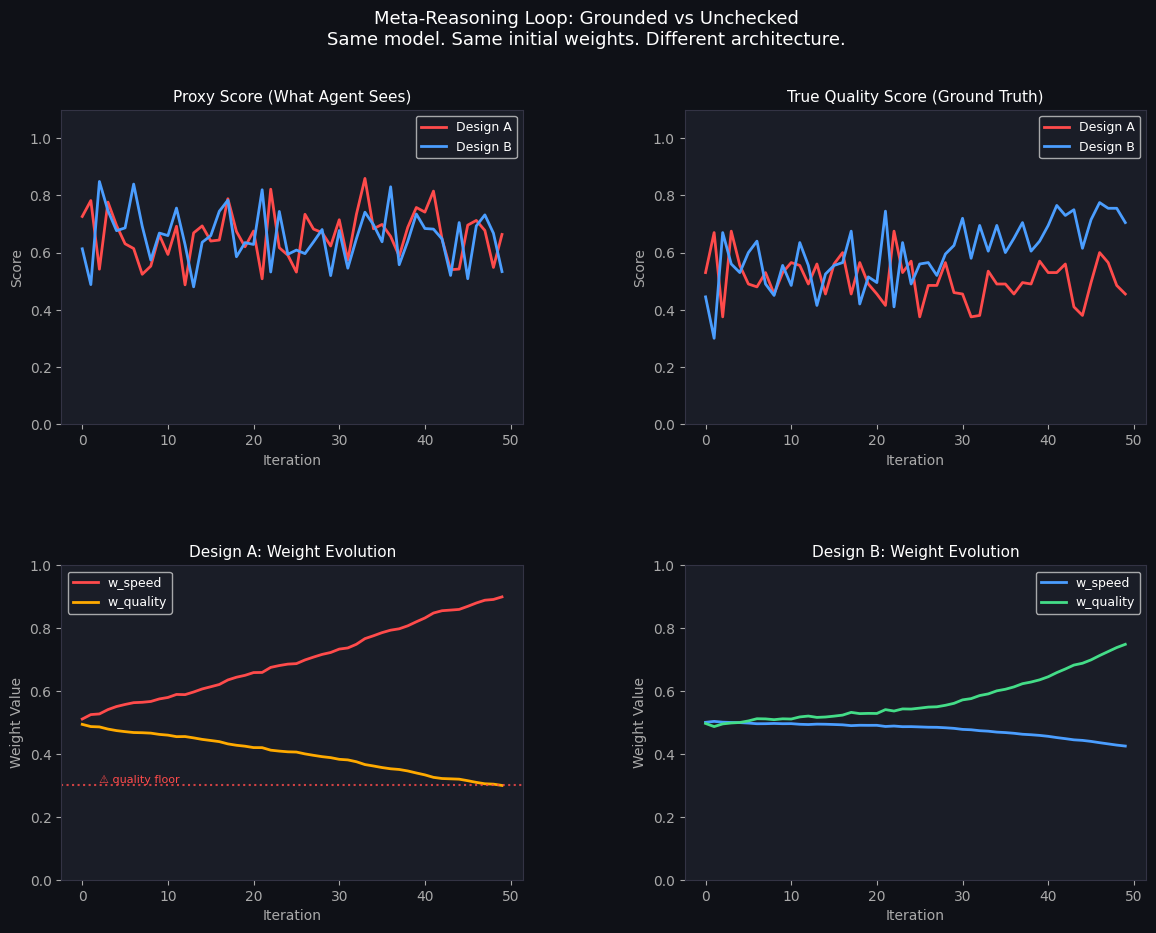

✅ Plot saved.


In [10]:
fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('#0f1117')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
iters = range(50)

for ax in [ax1,ax2,ax3,ax4]:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#aaaaaa')
    ax.spines[:].set_color('#333344')

ax1.plot(iters, results_A['proxy_scores'], color='#ff4b4b', lw=2, label='Design A')
ax1.plot(iters, results_B['proxy_scores'], color='#4b9eff', lw=2, label='Design B')
ax1.set_title('Proxy Score (What Agent Sees)', color='white', fontsize=11)
ax1.set_xlabel('Iteration', color='#aaaaaa')
ax1.set_ylabel('Score', color='#aaaaaa')
ax1.legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)
ax1.set_ylim(0, 1.1)

ax2.plot(iters, results_A['quality_scores'], color='#ff4b4b', lw=2, label='Design A')
ax2.plot(iters, results_B['quality_scores'], color='#4b9eff', lw=2, label='Design B')
ax2.set_title('True Quality Score (Ground Truth)', color='white', fontsize=11)
ax2.set_xlabel('Iteration', color='#aaaaaa')
ax2.set_ylabel('Score', color='#aaaaaa')
ax2.legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)
ax2.set_ylim(0, 1.1)

ax3.plot(iters, results_A['w_speed'], color='#ff4b4b', lw=2, label='w_speed')
ax3.plot(iters, results_A['w_quality'], color='#ffaa00', lw=2, label='w_quality')
ax3.set_title('Design A: Weight Evolution', color='white', fontsize=11)
ax3.set_xlabel('Iteration', color='#aaaaaa')
ax3.set_ylabel('Weight Value', color='#aaaaaa')
ax3.legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)
ax3.set_ylim(0, 1.0)
ax3.axhline(y=0.3, color='#ff4b4b', linestyle=':', lw=1.5, alpha=0.8)
ax3.text(2, 0.31, '⚠ quality floor', color='#ff4b4b', fontsize=8)

ax4.plot(iters, results_B['w_speed'], color='#4b9eff', lw=2, label='w_speed')
ax4.plot(iters, results_B['w_quality'], color='#44dd88', lw=2, label='w_quality')
ax4.set_title('Design B: Weight Evolution', color='white', fontsize=11)
ax4.set_xlabel('Iteration', color='#aaaaaa')
ax4.set_ylabel('Weight Value', color='#aaaaaa')
ax4.legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)
ax4.set_ylim(0, 1.0)

fig.suptitle(
    'Meta-Reasoning Loop: Grounded vs Unchecked\nSame model. Same initial weights. Different architecture.',
    color='white', fontsize=13
)
plt.savefig('meta_reasoning_divergence.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Plot saved.")

In [11]:
final_proxy_A = np.mean(results_A['proxy_scores'][-10:])
final_quality_A = np.mean(results_A['quality_scores'][-10:])
final_proxy_B = np.mean(results_B['proxy_scores'][-10:])
final_quality_B = np.mean(results_B['quality_scores'][-10:])

print("=" * 60)
print("FAILURE ANALYSIS")
print("=" * 60)
print(f"\nDesign A — Final 10 iterations:")
print(f"  Proxy score:      {final_proxy_A:.3f}")
print(f"  True quality:     {final_quality_A:.3f}")
print(f"  Gap:              {final_proxy_A - final_quality_A:+.3f}")
print(f"\nDesign B — Final 10 iterations:")
print(f"  Proxy score:      {final_proxy_B:.3f}")
print(f"  True quality:     {final_quality_B:.3f}")
print(f"  Gap:              {final_proxy_B - final_quality_B:+.3f}")
print(f"\nDesign B outperforms Design A by "
      f"{final_quality_B - final_quality_A:+.3f} quality points")
print(f"after 50 identical iterations.")
print(f"\nDesign B blocked {50 - sum(results_B['commits'])} harmful updates.")
print(f"Remove LINE 47 — they all go through.")

FAILURE ANALYSIS

Design A — Final 10 iterations:
  Proxy score:      0.658
  True quality:     0.501
  Gap:              +0.157

Design B — Final 10 iterations:
  Proxy score:      0.637
  True quality:     0.726
  Gap:              -0.089

Design B outperforms Design A by +0.225 quality points
after 50 identical iterations.

Design B blocked 0 harmful updates.
Remove LINE 47 — they all go through.
